In [1]:
import tiktoken

encoder = tiktoken.get_encoding("cl100k_base")  # GPT-4 tokenizer

texts = [
    "Hello world",
    "LangChain is amazing",
    "def fibonacci(n): return n if n <= 1 else fibonacci(n-1) + fibonacci(n-2)"
]

for text in texts:
    tokens = encoder.encode(text)
    print(f"Text: '{text}'")
    print(f"Tokens: {tokens}")
    print(f"Count: {len(tokens)}\n")

Text: 'Hello world'
Tokens: [9906, 1917]
Count: 2

Text: 'LangChain is amazing'
Tokens: [27317, 19368, 374, 8056]
Count: 4

Text: 'def fibonacci(n): return n if n <= 1 else fibonacci(n-1) + fibonacci(n-2)'
Tokens: [755, 76798, 1471, 1680, 471, 308, 422, 308, 2717, 220, 16, 775, 76798, 1471, 12, 16, 8, 489, 76798, 1471, 12, 17, 8]
Count: 23



In [2]:
# Cell 2: Understanding temperature
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()

question = "Give me a one-word color"

for temp in [0.0, 0.7, 1.5]:
    llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=temp)
    responses = [llm.invoke(question).content for _ in range(3)]
    print(f"Temperature {temp}: {responses}")

Temperature 0.0: ['Blue', 'Blue', 'Blue']
Temperature 0.7: ['Blue', 'Blue', 'Blue']
Temperature 1.5: ['Blue', 'Magenta', ' Purple']


In [3]:
# Cell 3: max_tokens controls response length
llm_short = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.7,
    max_tokens=20      # cuts off after 20 tokens
)

llm_long = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.7,
    max_tokens=500
)

q = "Explain how the internet works"
print("SHORT:", llm_short.invoke(q).content)
print("\nLONG:", llm_long.invoke(q).content)

SHORT: The internet is a global network of interconnected computers and servers that communicate with each other using standardized protocols.

LONG: The internet is a global network of interconnected computers and servers that communicate with each other using standardized protocols. Here's a simplified explanation of how the internet works:

**The Basics**

1. **IP Addresses**: Every device connected to the internet has a unique address, called an IP address (Internet Protocol address). This address allows devices to identify and communicate with each other.
2. **Packets**: When you send data over the internet, it's broken down into small packets of data. Each packet contains a portion of the data, along with the sender's and recipient's IP addresses.
3. **Protocols**: The internet uses a set of standardized protocols, such as TCP/IP (Transmission Control Protocol/Internet Protocol), to ensure that data is transmitted and received correctly.

**How Data is Transmitted**

1. **Your De

In [4]:
# Cell 4: System prompts in action
from langchain_core.messages import SystemMessage, HumanMessage

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.7)

# Without system prompt
response1 = llm.invoke("What is recursion?")
print("WITHOUT SYSTEM PROMPT:")
print(response1.content)
print("\n" + "="*60 + "\n")

# With system prompt - acts like a strict teacher
messages_teacher = [
    SystemMessage(content="You are a strict computer science professor. Always use technical terminology. Keep answers under 3 sentences."),
    HumanMessage(content="What is recursion?")
]
response2 = llm.invoke(messages_teacher)
print("AS STRICT PROFESSOR:")
print(response2.content)
print("\n" + "="*60 + "\n")

# Same question, different persona
messages_child = [
    SystemMessage(content="You are explaining concepts to a 10-year-old. Use simple words and fun analogies only."),
    HumanMessage(content="What is recursion?")
]
response3 = llm.invoke(messages_child)
print("FOR A 10-YEAR-OLD:")
print(response3.content)

WITHOUT SYSTEM PROMPT:
**Recursion**

Recursion is a fundamental concept in computer science and mathematics where a function or a process calls itself repeatedly until it reaches a base case that stops the recursion. In other words, a recursive function solves a problem by breaking it down into smaller sub-problems of the same type, which are then solved by the same function, until the solution to the original problem is found.

**Key Components of Recursion**
-----------------------------

1. **Base Case**: A base case is a trivial case that can be solved directly, without calling the function again. It serves as a stopping point for the recursion.
2. **Recursive Case**: A recursive case is a case where the function calls itself to solve a smaller instance of the same problem.
3. **Recursion Depth**: The recursion depth refers to the number of times the function calls itself before reaching the base case.

**How Recursion Works**
----------------------

Here's a step-by-step explanat

In [5]:
# Cell 5: invoke - waits for full response
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.7)

response = llm.invoke("Count from 1 to 5 slowly")
print("INVOKE (all at once):")
print(response.content)

INVOKE (all at once):
1... 
2... 
3... 
4... 
5...


In [6]:
# Cell 6: stream - token by token (like ChatGPT typing effect)
print("STREAM (token by token):")
for chunk in llm.stream("Count from 1 to 5 slowly"):
    print(chunk.content, end="", flush=True)
print()  # newline at end

STREAM (token by token):
1... 
2... 
3... 
4... 
5...


In [7]:
# Cell 7: batch - multiple prompts in one call (efficient)
questions = [
    "What is Python?",
    "What is JavaScript?",
    "What is Rust?"
]

print("BATCH (parallel):")
responses = llm.batch(questions)
for q, r in zip(questions, responses):
    print(f"Q: {q}")
    print(f"A: {r.content[:100]}...\n")  # first 100 chars

BATCH (parallel):
Q: What is Python?
A: **Python** is a high-level, interpreted programming language that is widely used for various purpose...

Q: What is JavaScript?
A: **JavaScript** is a high-level, dynamic, and interpreted programming language used for client-side s...

Q: What is Rust?
A: **Rust** is a systems programming language that prioritizes safety, performance, and concurrency. It...



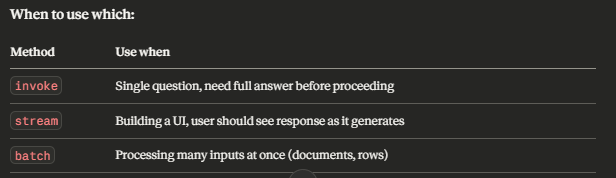

In [8]:
# Cell 8: PromptTemplate basics
from langchain_core.prompts import ChatPromptTemplate

# Define a reusable template
template = ChatPromptTemplate.from_messages([
    ("system", "You are an expert in {domain}. Always answer in {language}."),
    ("human", "{question}")
])

# Fill in variables
chain = template | llm  # pipe operator - we'll deep dive this tomorrow

# Use it
response = chain.invoke({
    "domain": "machine learning",
    "language": "simple English",
    "question": "What is overfitting?"
})
print(response.content)

Overfitting is a problem in machine learning. It happens when a model is too good at learning the data it was trained on, but not good at learning general rules.

Imagine you're trying to learn a game. If you practice on one board, you'll get very good at that one board. But if you play on a different board, you might not do well.

In machine learning, this means the model is too closely fit to the training data. It learns the noise and small details in the data, instead of the big patterns. This makes the model not work well on new, unseen data.

For example, if you train a model to recognize pictures of dogs and cats, but you only use pictures from one photographer, the model might learn to recognize the photographer's style instead of what makes a dog or cat. Then, when you show it pictures from a different photographer, it might not work well.

To avoid overfitting, we use things like:

* More data
* Simplifying the model
* Regularization (a way to limit the model's complexity)
* C

In [9]:
# Cell 9: Reuse same template with different inputs
inputs = [
    {"domain": "cooking", "language": "English", "question": "What is blanching?"},
    {"domain": "finance", "language": "English", "question": "What is compound interest?"},
    {"domain": "physics",  "language": "English", "question": "What is entropy?"},
]

for inp in inputs:
    resp = chain.invoke(inp)
    print(f"Domain: {inp['domain']}")
    print(f"Answer: {resp.content[:150]}...\n")

Domain: cooking
Answer: Blanching is a cooking technique where food, usually vegetables or fruits, are briefly submerged in boiling water or steam for a short period of time,...

Domain: finance
Answer: Compound interest is a fundamental concept in finance that refers to the interest earned on both the principal amount and any accrued interest over ti...

Domain: physics
Answer: Entropy is a fundamental concept in physics, particularly in thermodynamics. It is a measure of the disorder or randomness of a system. In other words...



In [10]:
# Cell 10: Track your token usage smartly
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.7)

response = llm.invoke("Explain decorators in Python in 2 sentences")

metadata = response.response_metadata
print("=== TOKEN USAGE ===")
print(f"Model: {metadata.get('model', 'N/A')}")

# Handle different metadata structures
usage = metadata.get('usage', metadata.get('token_usage', {}))
if hasattr(usage, '__dict__'):
    usage = usage.__dict__   # some versions return an object
    
print(f"Input tokens:  {usage.get('prompt_tokens', 'N/A')}")
print(f"Output tokens: {usage.get('completion_tokens', 'N/A')}")
print(f"Total tokens:  {usage.get('total_tokens', 'N/A')}")

=== TOKEN USAGE ===
Model: N/A
Input tokens:  44
Output tokens: 87
Total tokens:  131


- llama-3.3-70b-versatile → 14,400 requests/day, 131K tokens/min
- llama-3.1-8b-instant → 14,400 requests/day, 131K tokens/min
- When you hit limits → switch to Ollama locally, zero limits